In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys

In [12]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW  = ROOT / "data" / "raw" / "hillstrom.csv"
PROC = ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
FIG  = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
sys.path.append(str(ROOT / "src"))
sns.set_theme(style="whitegrid")

In [13]:
df = pd.read_csv("C:\\Users\\pgkvi\\OneDrive\\Desktop\\All Folders\\Bank Project\\CampusX\\customer-targeting-uplift\\data\\raw\\hillstrom.csv")
df.head()


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [14]:
print("\nMissing values:\n", df.isna().sum())
print("\nSegment counts:\n", df["segment"].value_counts())



Missing values:
 recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Segment counts:
 segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


## 2. Define treatment (any email vs control)

We combine men's + women's email into one **treated** group vs **control** (no email).
This gives the cleanest binary-treatment story and the largest treatment group.
Trade-off: the effect is the *average across both email types*.


In [15]:
seg = df["segment"].astype(str)
df["treatment"] = (~seg.str.contains("No", case=False)).astype(int)
print(df["treatment"].value_counts())
print("Treatment share: %.1f%%" % (100 * df["treatment"].mean()))

outcome_cols = ["visit", "conversion", "spend"]
id_like = ["segment", "treatment"]
covariates = [c for c in df.columns if c not in outcome_cols + id_like]
print("Pre-treatment covariates:", covariates)


treatment
1    42694
0    21306
Name: count, dtype: int64
Treatment share: 66.7%
Pre-treatment covariates: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']


In [16]:
df.head(), df.shape


(   recency history_segment  history  mens  womens   zip_code  newbie channel  \
 0       10  2) $100 - $200   142.44     1       0  Surburban       0   Phone   
 1        6  3) $200 - $350   329.08     1       1      Rural       1     Web   
 2        7  2) $100 - $200   180.65     0       1  Surburban       1     Web   
 3        9  5) $500 - $750   675.83     1       0      Rural       1     Web   
 4        2    1) $0 - $100    45.34     1       0      Urban       0     Web   
 
          segment  visit  conversion  spend  treatment  
 0  Womens E-Mail      0           0    0.0          1  
 1      No E-Mail      0           0    0.0          0  
 2  Womens E-Mail      0           0    0.0          1  
 3    Mens E-Mail      0           0    0.0          1  
 4  Womens E-Mail      0           0    0.0          1  ,
 (64000, 13))

## 3. Randomization balance checks

Confirm treatment & control are statistically identical on **pre-treatment**
covariates. Report a **standardized difference** (effect size) *and* a p-value.

With ~64k rows, p-values flag trivial differences as 'significant', so trust the
standardized difference. Rule of thumb: **|std diff| < 0.10 = well balanced.**


In [17]:
def standardized_diff_numeric(x_t, x_c):
    m_t, m_c = x_t.mean(), x_c.mean()
    pooled_sd = np.sqrt((x_t.var(ddof=1) + x_c.var(ddof=1)) / 2)
    return (m_t - m_c) / pooled_sd if pooled_sd > 0 else 0.0

t = df[df.treatment == 1]; c = df[df.treatment == 0]
rows = []
for col in covariates:
    if pd.api.types.is_numeric_dtype(df[col]):
        sd = standardized_diff_numeric(t[col], c[col])
        _, p = stats.ttest_ind(t[col], c[col], equal_var=False)
        rows.append({"covariate": col, "type": "numeric",
                     "treat_mean": round(t[col].mean(), 4),
                     "control_mean": round(c[col].mean(), 4),
                     "std_diff": round(sd, 4), "p_value": round(p, 4)})
    else:
        tbl = pd.crosstab(df[col], df["treatment"])
        chi2, p, _, _ = stats.chi2_contingency(tbl)
        rows.append({"covariate": col, "type": "categorical",
                     "treat_mean": np.nan, "control_mean": np.nan,
                     "std_diff": np.nan, "p_value": round(p, 4)})

balance = pd.DataFrame(rows)
display(balance)
balance.to_csv(PROC / "balance_table.csv", index=False)
print("|std_diff| < 0.10 => good balance. Trust std_diff over p-value at large n.")

,covariate,type,treat_mean,control_mean,std_diff,p_value
0,recency,numeric,5.7707,5.7497,0.0060,0.4738
1,history_segment,categorical,NaN,NaN,NaN,0.5047
2,history,numeric,242.6860,240.8827,0.0071,0.3982
3,mens,numeric,0.5499,0.5532,-0.0066,0.4306
4,womens,numeric,0.5508,0.5476,0.0063,0.4552
5,zip_code,categorical,NaN,NaN,NaN,0.5334
6,newbie,numeric,0.5024,0.5020,0.0008,0.9206
7,channel,categorical,NaN,NaN,NaN,0.8401


|std_diff| < 0.10 => good balance. Trust std_diff over p-value at large n.


**Result — randomization held.** Every standardized difference is far below the 0.10
threshold (largest ≈ 0.007 on `history`), so treatment and control are statistical
twins on all pre-treatment covariates. This validates the experiment: any downstream
difference in outcomes can be attributed to the email, not to pre-existing imbalance.
Note the large-sample lesson — some p-values look small even though the std-diffs are
trivial, which is why std-diff is the metric to trust at n = 64,000.

## 4. Outcome EDA — visit / conversion / spend

In [18]:
summary = df.groupby("treatment")[outcome_cols].mean()
summary.index = ["control", "treatment"]
display(summary)

control_conv = df.loc[df.treatment == 0, "conversion"].mean()
treat_conv   = df.loc[df.treatment == 1, "conversion"].mean()
print(f"Control conversion:   {control_conv*100:.3f}%")
print(f"Treatment conversion: {treat_conv*100:.3f}%")
print(f"Naive lift: {(treat_conv-control_conv)*100:.3f} pp")

,visit,conversion,spend
control,0.106167,0.005726,0.652789
treatment,0.167049,0.010681,1.249585


Control conversion:   0.573%
Treatment conversion: 1.068%
Naive lift: 0.495 pp


**Result — the funnel and the effect.** Conversion runs approx 0.57% (control) → ~1.07%
(treatment), a naïve lift of approx 0.50pp. Visit is far denser approx (10–17%), which is *why*
visit becomes the modeling outcome later: a denser signal is learnable, a rare one is
not. Spend is ~99% zeros — confirming it belongs as a guardrail, not a primary metric.

count    64000.000000
mean         1.050908
std         15.036448
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        499.000000
Name: spend, dtype: float64

% with spend == 0: 99.10%
Among spenders: mean=$116.36, median=$80.80, max=$499.00


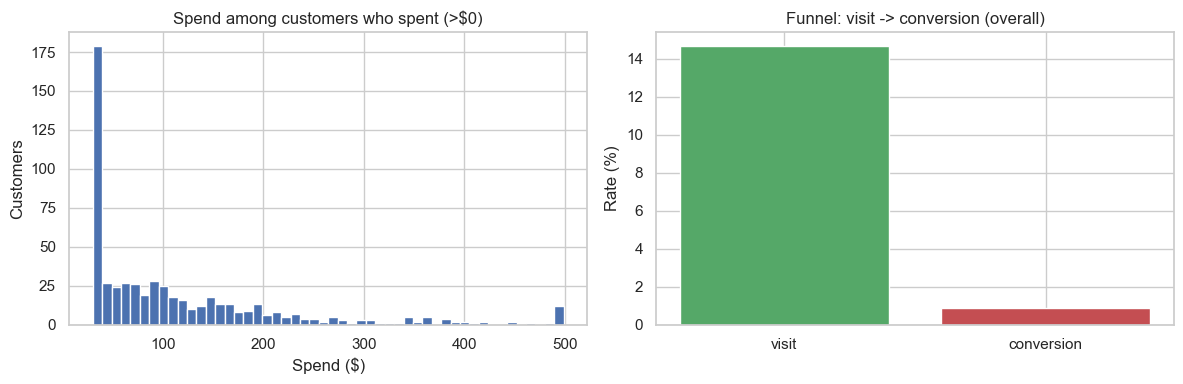

In [19]:
spend = df["spend"]
display(spend.describe())
print(f"% with spend == 0: {(spend==0).mean()*100:.2f}%")
nonzero = spend[spend > 0]
print(f"Among spenders: mean=${nonzero.mean():.2f}, median=${nonzero.median():.2f}, max=${nonzero.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(nonzero, bins=50, color="#4C72B0")
axes[0].set_title("Spend among customers who spent (>$0)")
axes[0].set_xlabel("Spend ($)"); axes[0].set_ylabel("Customers")
axes[1].bar(["visit", "conversion"],
            [df["visit"].mean()*100, df["conversion"].mean()*100],
            color=["#55A868", "#C44E52"])
axes[1].set_title("Funnel: visit -> conversion (overall)")
axes[1].set_ylabel("Rate (%)")
plt.tight_layout(); plt.savefig(FIG / "spend_and_funnel.png", dpi=120); plt.show()

#### The spend skew — why spend is a guardrail, not the primary metric

## 5. Recompute power with the real conversion rate

In [20]:
from power_analysis import min_detectable_rate

n_treat = int((df.treatment == 1).sum())
n_ctrl  = int((df.treatment == 0).sum())
n_min   = min(n_treat, n_ctrl)

mde_rate = min_detectable_rate(control_conv, n_min)
print(f"n control={n_ctrl:,}  n treatment={n_treat:,}  (limiting={n_min:,})")
print(f"Real control conversion: {control_conv*100:.3f}%")
print(f"Min detectable (alpha=.05, power=.80): {mde_rate*100:.3f}% "
      f"({(mde_rate-control_conv)*100:.3f}pp, {(mde_rate/control_conv-1)*100:.1f}% relative)")
print(f"Observed treatment: {treat_conv*100:.3f}% -> "
      f"{'DETECTABLE' if treat_conv >= mde_rate else 'borderline/below MDE'}")

n control=21,306  n treatment=42,694  (limiting=21,306)
Real control conversion: 0.573%
Min detectable (alpha=.05, power=.80): 0.796% (0.223pp, 38.9% relative)
Observed treatment: 1.068% -> DETECTABLE


In [21]:
df.to_csv(PROC / "hillstrom_clean.csv", index=False)
print("Saved ->", PROC / "hillstrom_clean.csv")
print("Sprint 2 complete.")

Saved -> C:\Users\pgkvi\OneDrive\Desktop\All Folders\Bank Project\CampusX\customer-targeting-uplift\data\processed\hillstrom_clean.csv
Sprint 2 complete.
